In [20]:
import os
import yaml
import h5py
import numpy as np
import matplotlib.pyplot as plt
from gwpy.segments import Segment
from gwpy.segments import SegmentList
from gw_anomaly_detection.data.segments import SegmentInfo
from gw_anomaly_detection.data.s3_utils import S3_session
from gw_anomaly_detection.data.waveforms import Waveforms
from gw_anomaly_detection.data.process import Process


In [21]:
os.chdir('/home/chiajui/gw-anomaly-detection')
print(os.getcwd())

/home/chiajui/gw-anomaly-detection


### Loading data_config.yaml

In [22]:
with open("./data_config.yaml", "r") as file:
    config = yaml.safe_load(file)

ifos = config['data']['ifos']
total_interval = config['data']['total_interval']
data_cache = config['data']['data_cache']
asd_cache = config['data']['asd_cache']

### Loading the information of the target segments.

In [23]:
seg_info = SegmentInfo()
background_segment_files = dict.fromkeys(ifos)
bg_segs = dict.fromkeys(ifos)
glitch_info_files = dict.fromkeys(ifos)
for ifo in ifos:
    background_segment_files[ifo] = config['data']['background']['segment_files'][ifo]
    interval = seg_info.whole_segment(segment_file=background_segment_files[ifo])
    bg_segs[ifo] = seg_info.read_segment_files(background_segment_files[ifo])
    print(f"Number of background segments from {ifo}: {len(bg_segs[ifo])}, interval: {interval}.")

glitch_segment_files = dict.fromkeys(ifos)
glitch_segs = dict.fromkeys(ifos)
for ifo in ifos:
    glitch_info_files[ifo] = config['data']['glitch']['glitch_info_files'][ifo]
    glitch_segment_files[ifo] = config['data']['glitch']['segment_files'][ifo]
    interval = seg_info.whole_segment(segment_file=glitch_segment_files[ifo])
    glitch_segs[ifo] = seg_info.read_segment_files(glitch_segment_files[ifo])
    print(f"Number of glitch segments from {ifo}: {len(glitch_segs[ifo])}, interval: {interval}.")

Number of background segments from H1: 5000, interval: (1238172998.370328, 1238196783.6153967).
Number of background segments from L1: 5000, interval: (1238205078.3146882, 1238228882.4192767).
Number of glitch segments from H1: 2284, interval: (1238172987.100586, 1238196787.949218).
Number of glitch segments from L1: 2589, interval: (1238205073.372314, 1238228876.15332).


### Generating Waveform.

In [5]:
ifos = config['data']['injection']['ifos']
segment_files = config['data']['injection']['segment_files']
background_segments = dict.fromkeys(ifos)
seg_info = SegmentInfo()
for ifo in ifos:
    background_segments[ifo] = seg_info.read_segment_files(segment_files[ifo])

number = config['data']['injection']['number']
waveform = config['data']['injection']['waveform']
qm_file = config['data']['injection']['qm_file']
sampling_frequency = config['data']['injection']['sampling_frequency']
target_snr_low = config['data']['injection']['target_snr_low']
target_snr_high = config['data']['injection']['target_snr_high']
keep_waveform = config['data']['injection']['keep_waveform']
output_file = config['data']['injection']['output_file']
length = config['data']['injection']['length']
flow = config['data']['processing']['flow']
fhigh = config['data']['processing']['fhigh']
resample = config['data']['processing']['resample']
crop_length = config['data']['processing']['crop_length']

proc = Process(
    ifos=ifos,
    data_cache=data_cache,
    asd_cache=asd_cache,
)

wav = Waveforms(
    ifos=ifos,
    length=length,
    sampling_frequency=sampling_frequency,
)
waveforms, params = wav.generate_waveforms(
    waveform,
    number,
    qm_file=qm_file,
)

TimeSeries([-1.00923696e-27, -1.02071200e-27, -1.03209948e-27,
            ...,  1.27639501e-28,  1.36110696e-28,
             1.44617444e-28]
           unit: dimensionless,
           t0: 0.0 s,
           dt: 6.103515625e-05 s,
           name: H1:BBH_SIG,
           channel: H1:BBH_SIG)
4.0 s
TimeSeries([ 1.44098826e-27,  1.43591121e-27,  1.43063137e-27,
            ..., -7.52845032e-28, -7.55688164e-28,
            -7.58409745e-28]
           unit: dimensionless,
           t0: 0.0 s,
           dt: 6.103515625e-05 s,
           name: L1:BBH_SIG,
           channel: L1:BBH_SIG)
4.0 s


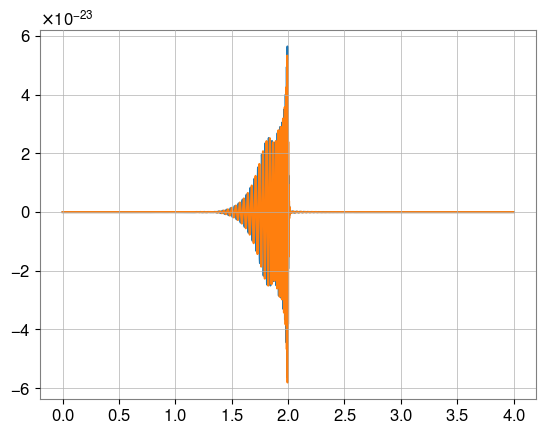

In [6]:
id = 2
print(waveforms[id]['H1'])
print(waveforms[id]['H1'].duration)
print(waveforms[id]['L1'])
print(waveforms[id]['L1'].duration)
plt.figure()
plt.plot(waveforms[id]['H1'])
plt.plot(waveforms[id]['L1'])
plt.show()

### Rescaling and Injection

In [7]:
injected_ts, rescaled_waveforms, snrs = proc.inject(
    waveforms=waveforms,
    target_snr_low=target_snr_low,
    target_snr_high=target_snr_high,
    background_segments=background_segments,
)

### Processing data.

In [8]:
timeseries = injected_ts
processed_data = proc.get_proccessed_data(
    timeseries=timeseries,
    background_segments=background_segments,
    flow=flow,
    fhigh=fhigh,
    resample=resample,
    crop_length=crop_length,
)
if keep_waveform:
    timeseries = rescaled_waveforms
    processed_waveforms = proc.get_proccessed_data(
        timeseries=timeseries,
        background_segments=background_segments,
        flow=flow,
        fhigh=fhigh,
        resample=resample,
        crop_length=crop_length,
    )

### Write data to hdf5 files

In [9]:
print(f"params: {len(params)}")
print(f"waveforms: {len(processed_waveforms)}")
print(f"snrs: {len(snrs)}")
print(f"processed_data: {len(processed_data)}")

print("")
print(waveform)
# print(params[0])
# print(snrs[0])

print(output_file)
# Write data to hdf5 files.
proc.write_injection_data(
    output_file=output_file,
    waveform_parameters=params,
    snrs=snrs,
    processed_data=processed_data,
    processed_waveforms=processed_waveforms,
)

params: 3
waveforms: 3
snrs: 3
processed_data: 3

bbh
/home/chiajui/test_data/injection_data.hdf5


### Checking written processed data

<KeysViewHDF5 ['H1', 'L1', 't0_H1', 't0_L1', 'waveform_H1', 'waveform_L1', 'waveform_parameters']>
<HDF5 dataset "waveform_parameters": shape (3,), type "|V224">
('Mc', 'q', 'a1', 'a2', 'tilt1', 'tilt2', 'phi12', 'phijl', 'thetajn', 'distance', 'phase', 'ra', 'dec', 'psi', 'mass1', 'mass2', 'f_ref', 'inclination', 'spin1x', 'spin1y', 'spin1z', 'spin2x', 'spin2y', 'spin2z', 'approximant', 'snr_H1', 'snr_L1', 'network_snr')
<HDF5 dataset "t0_H1": shape (3,), type "<f8">
<HDF5 dataset "H1": shape (3, 8192), type "<f8">
4096.0
<HDF5 dataset "waveform_H1": shape (3, 8192), type "<f8">
H1:BBH_SIG
<HDF5 dataset "t0_L1": shape (3,), type "<f8">
<HDF5 dataset "L1": shape (3, 8192), type "<f8">
4096.0
<HDF5 dataset "waveform_L1": shape (3, 8192), type "<f8">
L1:BBH_SIG


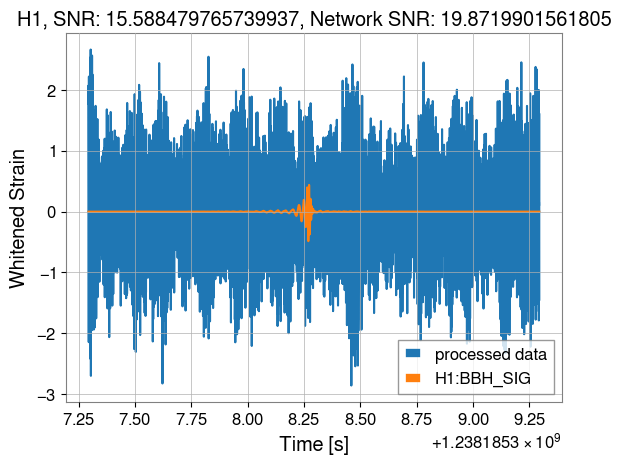

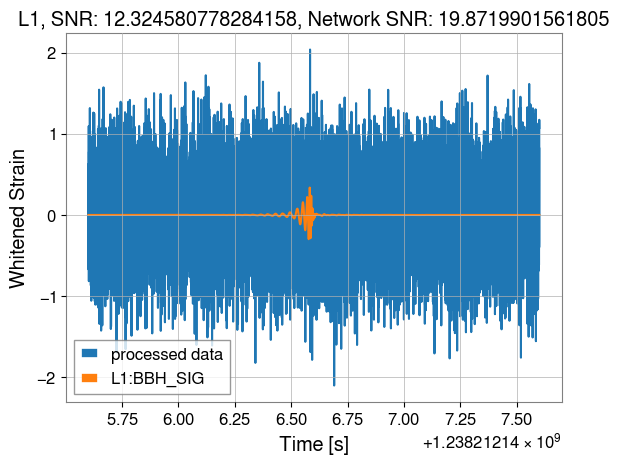

In [24]:
output_file = config['data']['injection']['output_file']
with h5py.File(output_file, 'r') as f:
    print(f.keys())
    print(f['waveform_parameters'])
    print(f['waveform_parameters'].dtype.names)
    print(f['t0_H1'])
    print(f['H1'])
    print(f['H1'].attrs['sample_rate'])
    print(f['waveform_H1'])
    print(f['waveform_H1'].attrs['channel'])
    print(f['t0_L1'])
    print(f['L1'])
    print(f['L1'].attrs['sample_rate'])
    print(f['waveform_L1'])
    print(f['waveform_L1'].attrs['channel'])

    id = 0
    for ifo in ifos:
        t0 = f[f't0_{ifo}'][id]
        sample_rate = f[ifo].attrs['sample_rate']
        times = np.arange(t0, t0+2, 1/sample_rate)
        waveform = f[f"waveform_{ifo}"].attrs['channel']
        snr = f['waveform_parameters'][id][f'snr_{ifo}']
        network_snr = f['waveform_parameters'][id][f'network_snr']
        plt.figure()
        plt.title(f"{ifo}, SNR: {snr}, Network SNR: {network_snr}")
        plt.plot(times, f[ifo][id], label='processed data')
        plt.plot(times, f[f'waveform_{ifo}'][id], label=waveform)
        plt.xlabel("Time [s]")
        plt.ylabel("Whitened Strain")
        plt.legend()
        plt.show()

### Processing glitches

In [19]:
ifos = config['data']['glitch']['ifos']
segment_files = config['data']['glitch']['segment_files']
glitch_segments = dict.fromkeys(ifos)
for ifo in ifos:
    glitch_segments[ifo] = seg_info.read_segment_files(segment_files[ifo])

start_id = config['data']['glitch']['start_id']
end_id = config['data']['glitch']['end_id']
glitch_info_files = config['data']['glitch']['glitch_info_files']
glitch_window_length = config['data']['glitch']['glitch_window_length']
output_file = config['data']['glitch']['output_file']

proc = Process(
    ifos=ifos,
    data_cache=data_cache,
    asd_cache=asd_cache,
)
processed_glitch, glitch_infos = proc.get_processed_glitch(
    glitch_segments=glitch_segments,
    start_id=start_id,
    end_id=end_id,
    glitch_info_files=glitch_info_files,
    glitch_window_length=glitch_window_length,
)

### Write processed glitch to hdf5 files

In [ ]:
output_file = config['data']['glitch']['output_file']
proc.write_glitch_data(
    output_file=output_file,
    processed_glitch=processed_glitch,
    glitch_infos=glitch_infos,
)

### Check written glitches

<KeysViewHDF5 ['H1', 'H1_glitch_info', 'L1', 'L1_glitch_info', 't0_H1', 't0_L1']>
H1:GLITCH


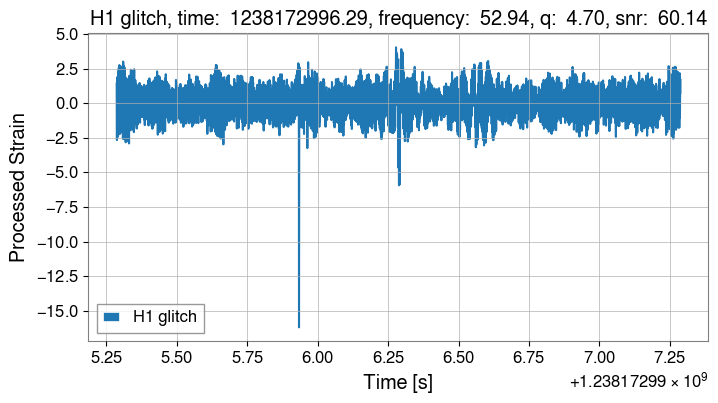

<KeysViewHDF5 ['H1', 'H1_glitch_info', 'L1', 'L1_glitch_info', 't0_H1', 't0_L1']>
L1:GLITCH


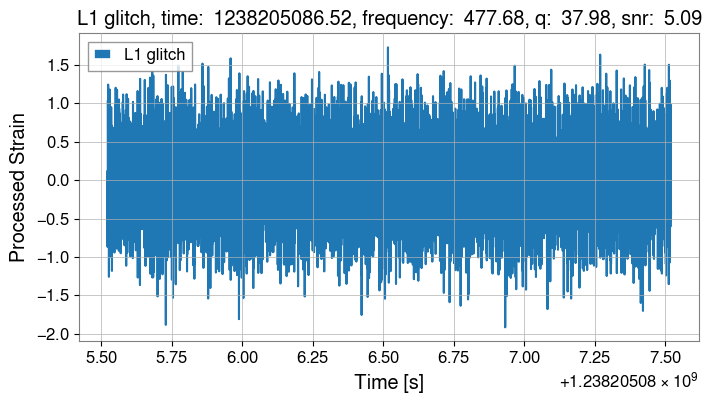

In [25]:
output_file = config['data']['glitch']['output_file']
id = 2
for ifo in ifos:
    with h5py.File(output_file, 'r') as f:
        print(f.keys())
        info = f[f'{ifo}_glitch_info'][id]
        data = f[ifo][id]
        t0 = f[f"t0_{ifo}"][id]
        sample_rate = f[ifo].attrs['sample_rate']
        print(f[ifo].attrs['channel'])
    
    times = np.arange(t0, t0 + 2, 1/sample_rate)
    plt.figure(figsize=[8,4])
    plt.title(f"{ifo} glitch, time: {info['time']: 2.2f}, frequency: {info['frequency']: 2.2f}, q: {info['q']: 2.2f}, snr: {info['snr']: 2.2f}")
    plt.plot(times, data, label=f"{ifo} glitch")
    plt.xlabel("Time [s]")
    plt.ylabel("Processed Strain")
    plt.legend()
    plt.show()

### Check Written Backgrounds

<KeysViewHDF5 ['H1', 'L1', 't0_H1', 't0_L1']>
H1:BACKGROUND_NOISE


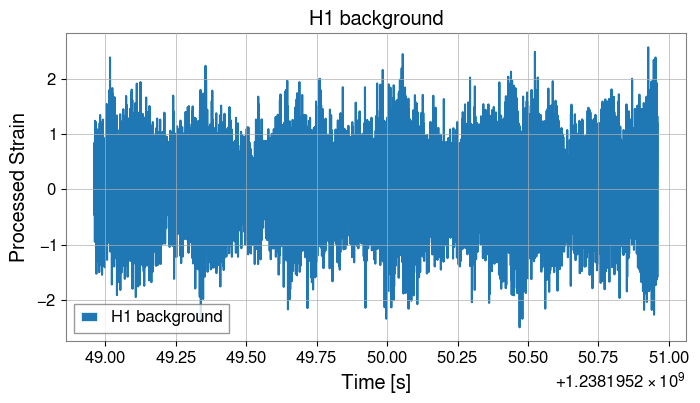

<KeysViewHDF5 ['H1', 'L1', 't0_H1', 't0_L1']>
L1:BACKGROUND_NOISE


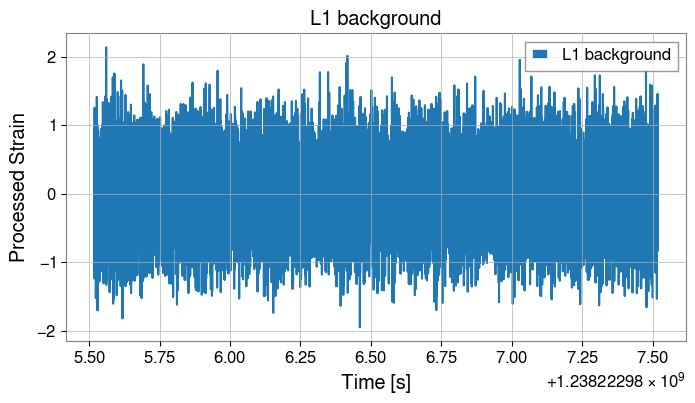

In [26]:
output_file = config['data']['background']['output_file']
id = 0
for ifo in ifos:
    with h5py.File(output_file, 'r') as f:
        print(f.keys())
        data = f[ifo][id]
        t0 = f[f"t0_{ifo}"][id]
        sample_rate = f[ifo].attrs['sample_rate']
        print(f[ifo].attrs['channel'])

    times = np.arange(t0, t0 + 2, 1/sample_rate)
    plt.figure(figsize=[8,4])
    plt.title(f"{ifo} background")
    plt.plot(times, data, label=f"{ifo} background")
    plt.xlabel("Time [s]")
    plt.ylabel("Processed Strain")
    plt.legend()
    plt.show()